Enter x1: 2
Enter y1: 5
Enter x2: 14
Enter y2: 15

--- DDA Line Drawing Algorithm ---
Starting Point: (2, 5)
Ending Point: (14, 15)
Delta X = 12
Delta Y = 10
Slope (m) = 0.8333333333333334

Case 1: |Delta X| >= |Delta Y|
x = 3
y = 6
pixel -> (3, 6)
x = 4
y = 7
pixel -> (4, 7)
x = 5
y = 7
pixel -> (5, 7)
x = 6
y = 8
pixel -> (6, 8)
x = 7
y = 9
pixel -> (7, 9)
x = 8
y = 10
pixel -> (8, 10)
x = 9
y = 11
pixel -> (9, 11)
x = 10
y = 12
pixel -> (10, 12)
x = 11
y = 13
pixel -> (11, 13)
x = 12
y = 13
pixel -> (12, 13)
x = 13
y = 14
pixel -> (13, 14)
x = 14
y = 15
pixel -> (14, 15)


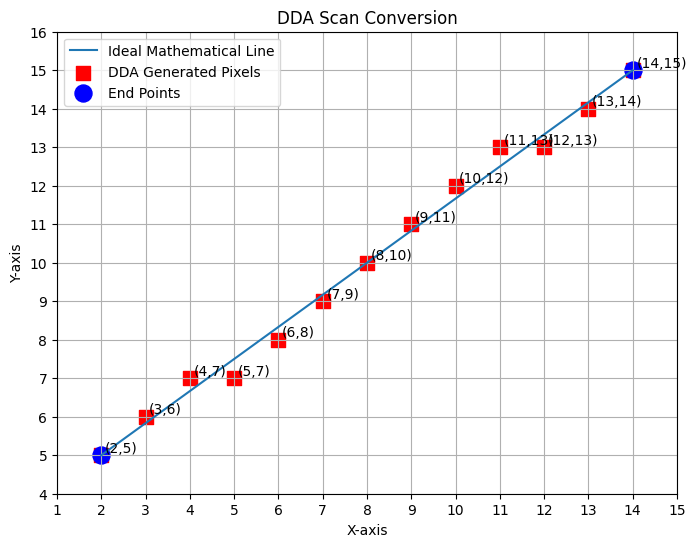

In [2]:
import matplotlib.pyplot as plt


def DDA_line(x1, y1, x2, y2):
    pixels = []

    print("\n--- DDA Line Drawing Algorithm ---")
    print("Starting Point:", (x1, y1))
    print("Ending Point:", (x2, y2))

    # Calculate delta x and delta y
    dx = x2 - x1
    dy = y2 - y1

    print("Delta X =", dx)
    print("Delta Y =", dy)

    # Vertical Line
    if dx == 0:
        print("\nCase: Vertical Line")

        step_y = 1 if dy > 0 else -1

        x = x1
        y = y1

        pixels.append((round(x), round(y)))

        while y != y2:
            y = y + step_y
            pixels.append((round(x), round(y)))

            print("x =", round(x))
            print("y =", round(y))
            print("pixel ->", (round(x), round(y)))

    else:
        # Calculate slope
        m = dy / dx

        print("Slope (m) =", m)

        # Case 1: |delta x| >= |delta y|
        if abs(dx) >= abs(dy):
            print("\nCase 1: |Delta X| >= |Delta Y|")

            # Delta X = 1 or -1
            step_x = 1 if dx > 0 else -1

            # x(i+1) = xi + Delta X
            # y(i+1) = yi + m * Delta X

            x = x1
            y = y1

            pixels.append((round(x), round(y)))

            while round(x) != x2:
                x = x + step_x
                y = y + m * step_x

                pixels.append((round(x), round(y)))

                print("x =", round(x))
                print("y =", round(y))
                print("pixel ->", (round(x), round(y)))

        # Case 2: |delta x| < |delta y|
        else:
            print("\nCase 2: |Delta X| < |Delta Y|")

            # Delta Y = 1 or -1
            step_y = 1 if dy > 0 else -1

            # x(i+1) = xi + Delta Y / m
            # y(i+1) = yi + Delta Y

            x = x1
            y = y1

            pixels.append((round(x), round(y)))

            while round(y) != y2:
                y = y + step_y
                x = x + step_y / m

                pixels.append((round(x), round(y)))

                print("x =", round(x))
                print("y =", round(y))
                print("pixel ->", (round(x), round(y)))

    return pixels

### Main Program ###

x1 = int(input("Enter x1: "))
y1 = int(input("Enter y1: "))
x2 = int(input("Enter x2: "))
y2 = int(input("Enter y2: "))

# Call DDA function
pixels = DDA_line(x1, y1, x2, y2)

### Plotting ###

x_pixels = [p[0] for p in pixels]
y_pixels = [p[1] for p in pixels]

plt.figure(figsize=(8, 6))

# Ideal mathematical line
plt.plot(
    [x1, x2],
    [y1, y2],
    label="Ideal Mathematical Line"
)

# Generated pixels
plt.scatter(
    x_pixels,
    y_pixels,
    s=100,
    marker="s",
    color="red",
    label="DDA Generated Pixels"
)

# End points
plt.scatter(
    [x1, x2],
    [y1, y2],
    s=150,
    marker="o",
    color="blue",
    label="End Points"
)

# Pixel coordinate labels
for x, y in pixels:
    plt.text(
        x + 0.08,
        y + 0.08,
        f"({x},{y})",
        fontsize=10
    )

plt.xticks(range(min(x1, x2) - 1, max(x1, x2) + 2))
plt.yticks(range(min(y1, y2) - 1, max(y1, y2) + 2))

plt.grid(True)
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("DDA Scan Conversion")
plt.legend()
plt.show()